# Classical Detector — Peak Amplitude Threshold
Each waveform is already z-score normalised (mean=0, std=1 per trace).
The idea: an earthquake has a burst of energy at P/S arrivals, so some samples will be
far from the mean. We measure `max(|x|)` per trace — the largest deviation in units of
std — and classify as earthquake if it exceeds a threshold.
Threshold is chosen to maximise F1 on the training set, then evaluated on the test set.

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import kurtosis
from sklearn.metrics import (
    f1_score, accuracy_score, precision_score, recall_score,
    roc_auc_score, confusion_matrix, classification_report,
    ConfusionMatrixDisplay, RocCurveDisplay,
)

## Load data

In [5]:
X    = np.load("../data/waveforms.npy")                       # (N, 6000), z-score normalised
meta = pd.read_csv("../data/metadata.csv", low_memory=False)

labels = meta["label"].values
splits = meta["split"].values

train_mask = splits == "train"
val_mask   = splits == "val"
test_mask  = splits == "test"

print(f"Waveforms    : {X.shape}")
print(f"Earthquakes  : {(labels==1).sum():,}  |  Noise: {(labels==0).sum():,}")
print(f"Train / Val / Test : {train_mask.sum():,} / {val_mask.sum():,} / {test_mask.sum():,}")

Waveforms    : (427770, 6000)
Earthquakes  : 193,424  |  Noise: 234,346
Train / Val / Test : 256,691 / 64,158 / 106,921


## Compute features
`max_abs`: maximum absolute value per trace — the furthest any sample is from the mean, in units of std.

`kurt`: excess kurtosis — measures how 'peaky' the amplitude distribution is. An earthquake burst creates a few extreme values, giving high kurtosis, while noise is more Gaussian (kurtosis ≈ 0).

In [6]:
print("Computing max absolute deviation...")
max_abs = np.abs(X).max(axis=1)          # (N,)  — max|x| since data is already z-scored

print("Computing kurtosis...")
kurt = kurtosis(X, axis=1)               # (N,)  — excess kurtosis along time axis

print("Done.")
print(f"\nmax_abs  — Earthquakes: {max_abs[labels==1].mean():.2f} ± {max_abs[labels==1].std():.2f}")
print(f"           Noise      : {max_abs[labels==0].mean():.2f} ± {max_abs[labels==0].std():.2f}")
print(f"\nkurtosis — Earthquakes: {kurt[labels==1].mean():.2f} ± {kurt[labels==1].std():.2f}")
print(f"           Noise      : {kurt[labels==0].mean():.2f} ± {kurt[labels==0].std():.2f}")

Computing max absolute deviation...
Computing kurtosis...
Done.

max_abs  — Earthquakes: 14.20 ± 6.25
           Noise      : 4.89 ± 2.67

kurtosis — Earthquakes: 56.48 ± 75.73
           Noise      : 3.88 ± 31.84


## Visualise feature distributions

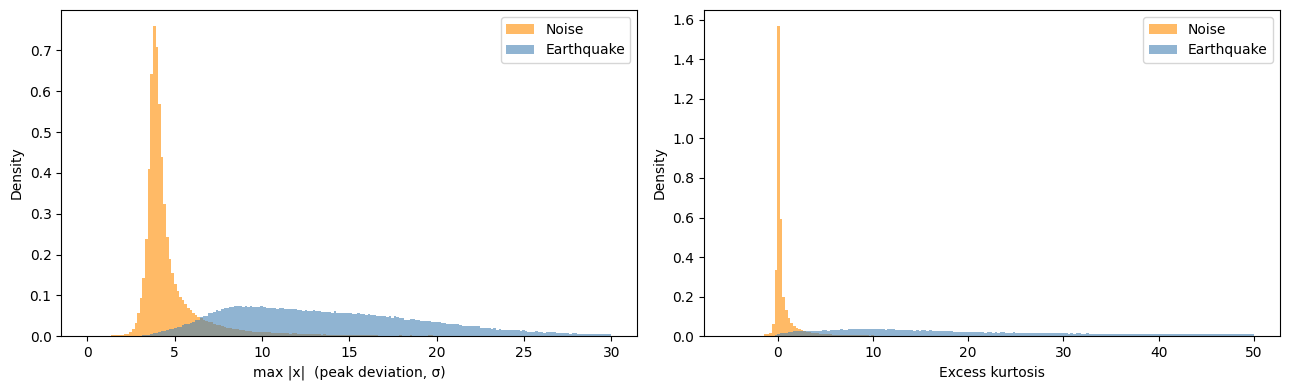

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, feat, name, xlim in [
    (axes[0], max_abs, "max |x|  (peak deviation, σ)", (0, 30)),
    (axes[1], kurt,    "Excess kurtosis",               (-5, 50)),
]:
    ax.hist(feat[labels==0], bins=200, range=xlim, alpha=0.6, color="darkorange", label="Noise",      density=True)
    ax.hist(feat[labels==1], bins=200, range=xlim, alpha=0.6, color="steelblue",  label="Earthquake", density=True)
    ax.set_xlabel(name)
    ax.set_ylabel("Density")
    ax.legend()

plt.tight_layout()
plt.show()

## Find optimal threshold on training set
Sweep 1000 candidate thresholds for `max_abs` and pick the one with the highest F1.

Best threshold : 6.527 σ
Train F1       : 0.9000


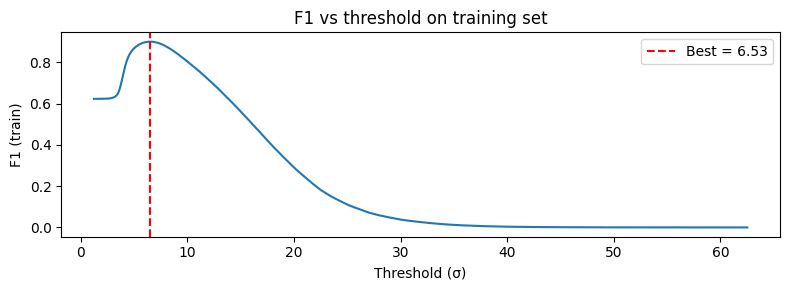

In [8]:
train_feat   = max_abs[train_mask]
train_labels = labels[train_mask]

thresholds = np.linspace(train_feat.min(), train_feat.max(), 1000)
f1_scores  = [
    f1_score(train_labels, (train_feat > t).astype(int), zero_division=0)
    for t in thresholds
]

best_idx       = int(np.argmax(f1_scores))
best_threshold = thresholds[best_idx]
best_f1        = f1_scores[best_idx]

print(f"Best threshold : {best_threshold:.3f} σ")
print(f"Train F1       : {best_f1:.4f}")

plt.figure(figsize=(8, 3))
plt.plot(thresholds, f1_scores)
plt.axvline(best_threshold, color="red", linestyle="--", label=f"Best = {best_threshold:.2f}")
plt.xlabel("Threshold (σ)")
plt.ylabel("F1 (train)")
plt.title("F1 vs threshold on training set")
plt.legend()
plt.tight_layout()
plt.show()

## Evaluate on test set

In [9]:
test_feat   = max_abs[test_mask]
test_labels = labels[test_mask]
test_preds  = (test_feat > best_threshold).astype(int)

# Use max_abs as a continuous score for ROC / AUC
# (higher max_abs → more likely earthquake)
test_scores = test_feat

## Metrics

In [10]:
print("=" * 50)
print("Test set metrics")
print("=" * 50)
print(classification_report(test_labels, test_preds, target_names=["Noise", "Earthquake"], digits=4))
print(f"F1 (macro)   : {f1_score(test_labels, test_preds, average='macro'):.4f}")
print(f"F1 (weighted): {f1_score(test_labels, test_preds, average='weighted'):.4f}")
print(f"Accuracy     : {accuracy_score(test_labels, test_preds):.4f}")
print(f"Precision    : {precision_score(test_labels, test_preds):.4f}")
print(f"Recall       : {recall_score(test_labels, test_preds):.4f}")
print(f"AUC-ROC      : {roc_auc_score(test_labels, test_scores):.4f}")

Test set metrics
              precision    recall  f1-score   support

       Noise     0.9414    0.8809    0.9101     58588
  Earthquake     0.8661    0.9335    0.8985     48333

    accuracy                         0.9047    106921
   macro avg     0.9037    0.9072    0.9043    106921
weighted avg     0.9073    0.9047    0.9049    106921

F1 (macro)   : 0.9043
F1 (weighted): 0.9049
Accuracy     : 0.9047
Precision    : 0.8661
Recall       : 0.9335
AUC-ROC      : 0.9576


## Confusion matrix & ROC curve

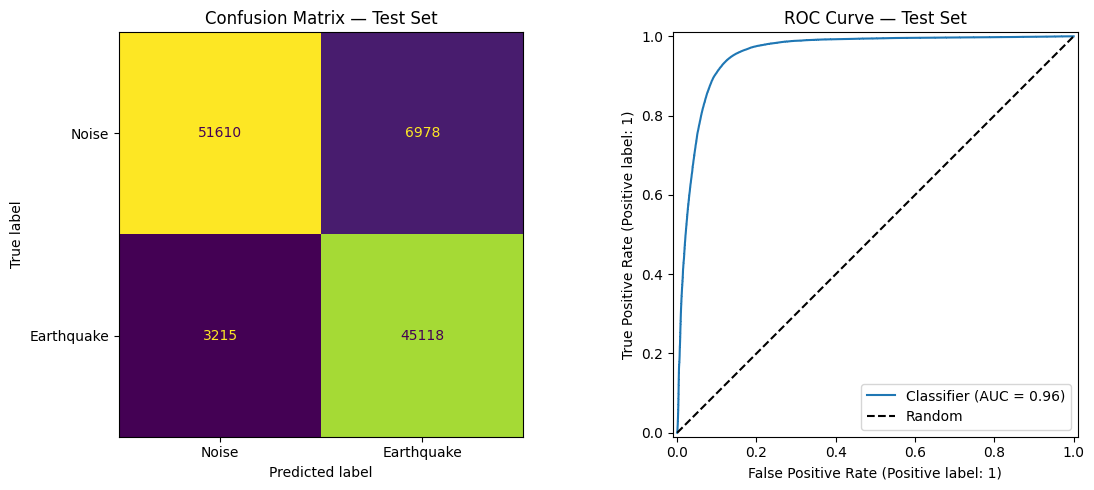

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay(
    confusion_matrix(test_labels, test_preds),
    display_labels=["Noise", "Earthquake"],
).plot(ax=axes[0], colorbar=False)
axes[0].set_title("Confusion Matrix — Test Set")

RocCurveDisplay.from_predictions(test_labels, test_scores, ax=axes[1])
axes[1].plot([0, 1], [0, 1], "k--", label="Random")
axes[1].set_title("ROC Curve — Test Set")
axes[1].legend()

plt.tight_layout()
plt.show()